<a href="https://colab.research.google.com/github/ShakthivelNadar/Customer-Churn-Prediction/blob/main/CustomerChurnPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
df = pd.read_csv("/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
df.drop("customerID", axis=1, inplace=True)

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [5]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [6]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

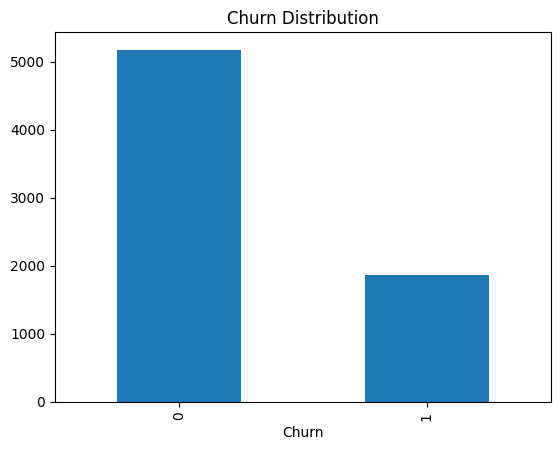

In [7]:
df["Churn"].value_counts().plot(kind="bar", title="Churn Distribution")
plt.show()

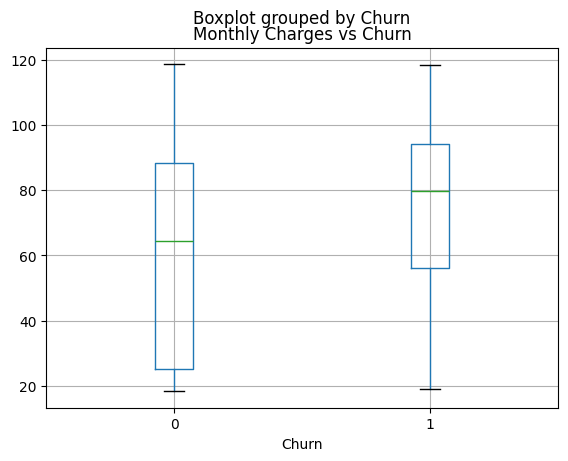

In [8]:
df.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly Charges vs Churn")
plt.show()

In [9]:
cat_cols = df.select_dtypes(include="object").columns

In [10]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [11]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [14]:
param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4]}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [15]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8026969481902059


In [16]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [17]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[937  98]
 [180 194]]


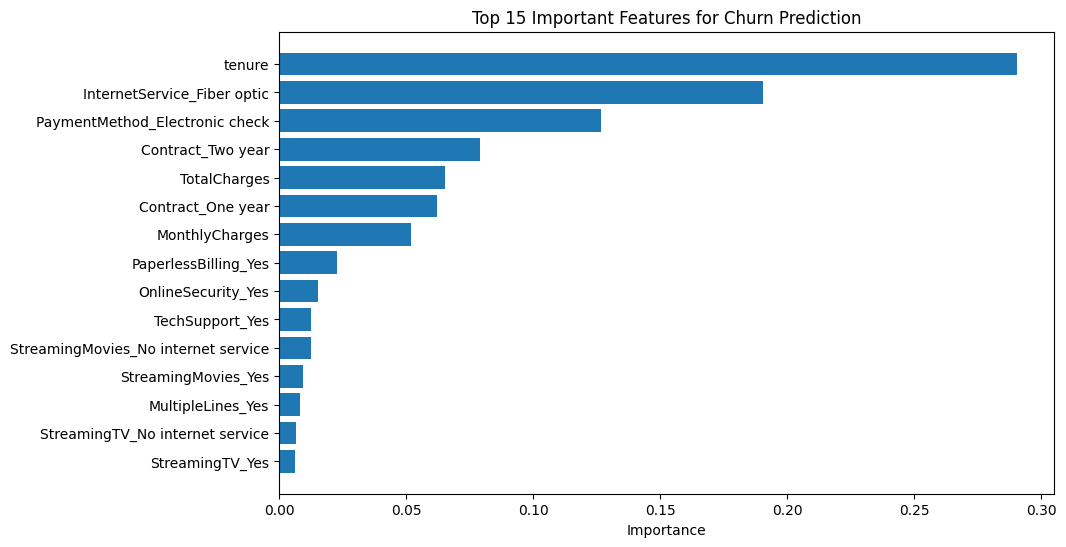

In [18]:
feature_importance = best_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Top 15 Important Features for Churn Prediction")
plt.gca().invert_yaxis()
plt.show()

In [19]:
unseen_df = pd.DataFrame({
    "customerID": ["U101", "U102", "U103", "U104", "U105"],
    "gender": ["Female", "Male", "Female", "Male", "Female"],
    "SeniorCitizen": [0, 0, 1, 0, 0],
    "Partner": ["Yes", "No", "Yes", "No", "Yes"],
    "Dependents": ["No", "No", "Yes", "No", "Yes"],
    "tenure": [3, 36, 10, 72, 6],
    "PhoneService": ["Yes", "Yes", "Yes", "Yes", "Yes"],
    "MultipleLines": ["No", "Yes", "No", "Yes", "No"],
    "InternetService": ["Fiber optic", "DSL", "Fiber optic", "DSL", "Fiber optic"],
    "OnlineSecurity": ["No", "Yes", "No", "Yes", "No"],
    "OnlineBackup": ["No", "Yes", "Yes", "Yes", "No"],
    "DeviceProtection": ["No", "Yes", "No", "Yes", "No"],
    "TechSupport": ["No", "Yes", "No", "Yes", "No"],
    "StreamingTV": ["Yes", "No", "Yes", "Yes", "No"],
    "StreamingMovies": ["Yes", "No", "No", "Yes", "No"],
    "Contract": ["Month-to-month", "One year", "Month-to-month", "Two year", "Month-to-month"],
    "PaperlessBilling": ["Yes", "No", "Yes", "No", "Yes"],
    "PaymentMethod": [
        "Electronic check",
        "Bank transfer (automatic)",
        "Electronic check",
        "Credit card (automatic)",
        "Mailed check"
    ],
    "MonthlyCharges": [89.9, 55.5, 96.3, 78.2, 70.4],
    "TotalCharges": [269.7, 1998.0, 963.0, 5630.0, 422.4]
})

unseen_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,U101,Female,0,Yes,No,3,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.9,269.7
1,U102,Male,0,No,No,36,Yes,Yes,DSL,Yes,Yes,Yes,Yes,No,No,One year,No,Bank transfer (automatic),55.5,1998.0
2,U103,Female,1,Yes,Yes,10,Yes,No,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,96.3,963.0
3,U104,Male,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),78.2,5630.0
4,U105,Female,0,Yes,Yes,6,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.4,422.4


In [20]:
# drop ID
unseen_features = unseen_df.drop("customerID", axis=1)

# encode
unseen_encoded = pd.get_dummies(unseen_features, drop_first=True)

# align columns
unseen_encoded = unseen_encoded.reindex(columns=X.columns, fill_value=0)

# scale
unseen_scaled = scaler.transform(unseen_encoded)

# predict
unseen_pred = best_model.predict(unseen_scaled)
unseen_prob = best_model.predict_proba(unseen_scaled)

# results
results = unseen_df.copy()
results["Predicted Churn"] = unseen_pred
results["Churn Probability"] = unseen_prob[:, 1]

results

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Predicted Churn,Churn Probability
0,U101,Female,0,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.9,269.7,1,0.795994
1,U102,Male,0,No,No,36,Yes,Yes,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),55.5,1998.0,0,0.047822
2,U103,Female,1,Yes,Yes,10,Yes,No,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Electronic check,96.3,963.0,1,0.740005
3,U104,Male,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Two year,No,Credit card (automatic),78.2,5630.0,0,0.018153
4,U105,Female,0,Yes,Yes,6,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,70.4,422.4,1,0.577069
